In [2]:
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets

torch.cuda.is_available()

True

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
file_path = '/content/drive/MyDrive/Colab Notebooks/datasets/beatles.txt'

with open(file_path, 'r') as f:
    text = f.read()
if(text):
  print("data read succesfully")
  print(f'total characters {len(text)}')

data read succesfully
total characters 157064


In [5]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)


 !"'(),-./0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWY[]abcdefghijklmnopqrstuvwxyzöü
78


In [6]:
stoi = { ch:i for i,ch in enumerate(chars)}
itos  = {i:ch for i,ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

print(encode("hii there"))
print(decode(encode("hi there")))

[57, 58, 58, 1, 69, 57, 54, 67, 54]
hi there


In [7]:
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)
print(data[:1000])

torch.Size([157064]) torch.int64
tensor([ 0,  0,  0,  0, 24, 52, 67, 64, 68, 68,  1, 43, 57, 54,  1, 44, 63, 58,
        71, 54, 67, 68, 54,  0,  5,  1, 33,  9,  1, 35, 54, 63, 63, 64, 63,  7,
         1, 39,  9,  1, 36, 52, 26, 50, 67, 69, 63, 54, 74,  6,  0,  0, 46, 64,
        67, 53, 68,  1, 50, 67, 54,  1, 55, 61, 74, 58, 63, 56,  1, 64, 70, 69,
         1, 61, 58, 60, 54,  1, 54, 63, 53, 61, 54, 68, 68,  1, 67, 50, 58, 63,
         1, 58, 63, 69, 64,  1, 50,  1, 65, 50, 65, 54, 67,  1, 52, 70, 65,  7,
         0, 43, 57, 54, 74,  1, 68, 61, 58, 69, 57, 54, 67,  1, 72, 57, 58, 61,
        54,  7,  1, 69, 57, 54, 74,  1, 65, 50, 68, 68,  7,  1, 69, 57, 54, 74,
         1, 68, 61, 58, 65,  1, 50, 72, 50, 74,  1, 50, 52, 67, 64, 68, 68,  1,
        69, 57, 54,  1, 70, 63, 58, 71, 54, 67, 68, 54,  0, 39, 64, 64, 61, 68,
         1, 64, 55,  1, 68, 64, 67, 67, 64, 72,  7,  1, 72, 50, 71, 54, 68,  1,
        64, 55,  1, 59, 64, 74,  1, 50, 67, 54,  1, 53, 67, 58, 55, 69, 58, 63,
       

In [8]:
n = int(0.9*len(data))
train_data = data[:n]
val_data = data[n:]

In [9]:
block_size = 8
train_data[:block_size+1]

tensor([ 0,  0,  0,  0, 24, 52, 67, 64, 68])

In [10]:
x = train_data[:block_size]
y = train_data[1:block_size+1]
for t in range(block_size):
  context = x[:t+1]
  target = y[t]
  print(f"when input is {context} the target: {target}")

when input is tensor([0]) the target: 0
when input is tensor([0, 0]) the target: 0
when input is tensor([0, 0, 0]) the target: 0
when input is tensor([0, 0, 0, 0]) the target: 24
when input is tensor([ 0,  0,  0,  0, 24]) the target: 52
when input is tensor([ 0,  0,  0,  0, 24, 52]) the target: 67
when input is tensor([ 0,  0,  0,  0, 24, 52, 67]) the target: 64
when input is tensor([ 0,  0,  0,  0, 24, 52, 67, 64]) the target: 68


In [11]:
torch.manual_seed(1337)
batch_size = 4 #number of independent sequences
block_size = 8 #maximum context length in prediction

def get_batch(split):
  data = train_data if split == 'train' else val_data
  ix = torch.randint(len(data) - block_size, (batch_size,))
  x = torch.stack([data[i:i+block_size] for i in ix])
  y = torch.stack([data[i+1:i+block_size+1] for i in ix])
  return x, y

xb, yb = get_batch('train')
print('input')
print(xb.shape)
print(xb)
print('targets:')
print(yb.shape)
print(yb)


input
torch.Size([4, 8])
tensor([[63,  7,  1, 61, 58, 69, 69, 61],
        [63, 56, 54,  1, 62, 74,  1, 72],
        [74,  1, 53, 50, 74, 68,  1, 74],
        [ 8, 64, 50, 63, 23,  3,  0, 25]])
targets:
torch.Size([4, 8])
tensor([[ 7,  1, 61, 58, 69, 69, 61, 54],
        [56, 54,  1, 62, 74,  1, 72, 64],
        [ 1, 53, 50, 74, 68,  1, 74, 64],
        [64, 50, 63, 23,  3,  0, 25, 70]])


In [12]:
class BigramLanguageModel(nn.Module):
  def __init__(self, vocab_size):
    super().__init__()
    self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

  def forward(self, idx, targets=None):
    logits = self.token_embedding_table(idx) # B,T,C

    if targets is None:
      loss = None
    else:
      B, T, C = logits.shape
      logits = logits.view(B*T, C)
      targets = targets.view(B*T)

      loss = F.cross_entropy(logits, targets)

    return logits, loss

  def generate(self, idx, max_new_tokens):
    for _ in range(max_new_tokens):
      logits, loss = self(idx)
      logits = logits[:, -1, :]
      probs = F.softmax(logits, dim=-1)
      idx_next = torch.multinomial(probs, num_samples=1)
      idx = torch.cat((idx, idx_next), dim=1)
    return idx

m = BigramLanguageModel(vocab_size)
logits, loss = m(xb, yb)
print(logits.shape)
print(loss)


idx = torch.zeros((1,1), dtype=torch.long)
print(decode(m.generate(idx = torch.zeros((1,1),dtype=torch.long), max_new_tokens = 100)[0].tolist()))

torch.Size([32, 78])
tensor(4.7430, grad_fn=<NllLossBackward0>)

zeDm6tmL7ntzy:x/?dJ.vARSske?l!5stxJS7-kIJ;"WCüd'E2N90GR[37bqR/(Tö48W6lKSprL/IjaF[YP7Cnsins1tAc0KkxV2


In [13]:
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)

In [14]:
batch_size = 32
for steps in range(10000):
  xb, yb = get_batch('train')

  logits, loss = m(xb, yb)
  optimizer.zero_grad(set_to_none=True)
  loss.backward()
  optimizer.step()

print(loss.item())

2.3333539962768555


In [15]:
print(decode(m.generate(idx = torch.zeros((1,1),dtype=torch.long), max_new_tokens = 100)[0].tolist()))


I'relowhet
Re,
Ler I'verithou'then ceven s'thil,
Lpl y t wireaveas  y cainouthoune suryou y m lol so


Mathematical Stuff starts:

In [16]:
#how to use matrix multiplication for weighted aggregation:
torch.manual_seed(42)
a = torch.tril(torch.ones(3,3)) #returns a upper triangular 3 x 3 matrix
a = a/torch.sum(a, 1, keepdim=True)
b = torch.randint(0,10,(3,2)).float()
c = a @ b
print('a=')
print(a)
print('--')
print('b=')
print(b)
print('--')
print('c=')
print(c)
print('--')


a=
tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])
--
b=
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
--
c=
tensor([[2.0000, 7.0000],
        [4.0000, 5.5000],
        [4.6667, 5.3333]])
--


In [17]:
B, T, C = 4,8,2
x = torch.randn(B, T, C)
x.shape

torch.Size([4, 8, 2])

In [18]:
# We want x[b,t] = mean_{i<=t} x[b,i]
xbow = torch.zeros((B, T, C))
for b in range(B):
  for t in range(T):
    xprev = x[b,:t+1]
    xbow[b,t] = torch.mean(xprev, 0)

In [22]:
#use softmax
tril = torch.tril(torch.ones(T, T))
wei = torch.zeros((T, T))
wei = wei.masked_fill(tril ==0, float('-inf'))
wei  = F.softmax(wei, dim=-1)
xbow3 = wei @ x
torch.allclose(xbow, xbow3)

True

In [25]:
import torch
import torch.nn as nn
from torch.nn import functional as F

# hyperparameters
batch_size = 16 # how many independent sequences will we process in parallel?
block_size = 32 # what is the maximum context length for predictions?
max_iters = 5000
eval_interval = 100
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 64
n_head = 4
n_layer = 4
dropout = 0.0
# ------------

torch.manual_seed(1337)

file_path = '/content/drive/MyDrive/Colab Notebooks/datasets/beatles.txt'

with open(file_path, 'r') as f:
    text = f.read()
if(text):
  print("data read succesfully")
  print(f'total characters {len(text)}')

# here are all the unique characters that occur in this text
chars = sorted(list(set(text)))
vocab_size = len(chars)
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

# Train and test splits
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

# data loading
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)   # (B,T,C)
        q = self.query(x) # (B,T,C)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * C**-0.5 # (B, T, C) @ (B, C, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x) # (B,T,C)
        out = wei @ v # (B, T, T) @ (B, T, C) -> (B, T, C)
        return out

class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

# super simple bigram model
class BigramLanguageModel(nn.Module):

    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

model = BigramLanguageModel()
m = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# Initialize lists to store loss history for plotting
train_loss_history = []
val_loss_history = []
iteration_history = []

for iter in range(max_iters):

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
        # Store losses for plotting
        train_loss_history.append(losses['train'].item())
        val_loss_history.append(losses['val'].item())
        iteration_history.append(iter)

    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

# generate from the model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(m.generate(context, max_new_tokens=2000)[0].tolist()))


data read succesfully
total characters 157064
0.211406 M parameters
step 0: train loss 4.5505, val loss 4.5580
step 100: train loss 2.5393, val loss 2.6349
step 200: train loss 2.4125, val loss 2.5206
step 300: train loss 2.2659, val loss 2.4030
step 400: train loss 2.1821, val loss 2.3335
step 500: train loss 2.0864, val loss 2.2750
step 600: train loss 2.0044, val loss 2.2146
step 700: train loss 1.9382, val loss 2.1591
step 800: train loss 1.8762, val loss 2.1247
step 900: train loss 1.8140, val loss 2.0868
step 1000: train loss 1.7665, val loss 2.0734
step 1100: train loss 1.7373, val loss 2.0358
step 1200: train loss 1.6892, val loss 2.0122
step 1300: train loss 1.6754, val loss 1.9792
step 1400: train loss 1.6275, val loss 2.0072
step 1500: train loss 1.6097, val loss 2.0058
step 1600: train loss 1.5721, val loss 1.9467
step 1700: train loss 1.5677, val loss 2.0066
step 1800: train loss 1.5422, val loss 1.9595
step 1900: train loss 1.5187, val loss 1.9472
step 2000: train loss 1.

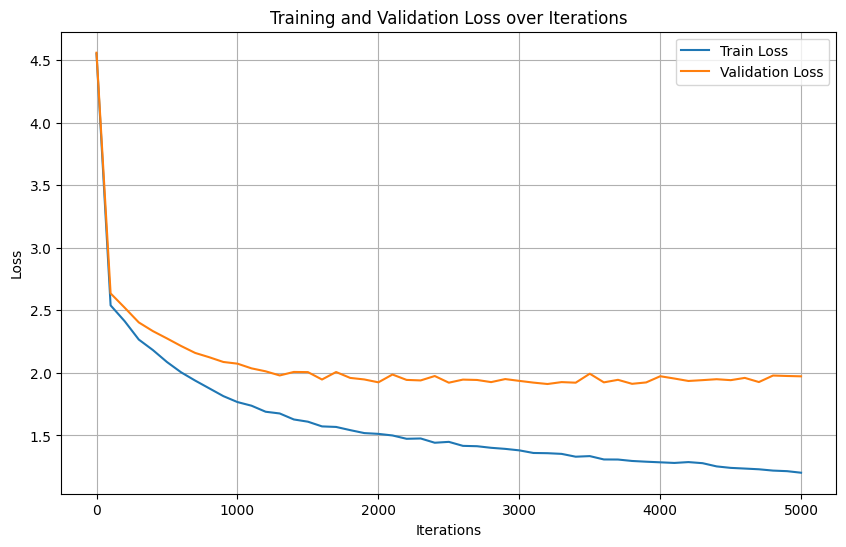

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(iteration_history, train_loss_history, label='Train Loss')
plt.plot(iteration_history, val_loss_history, label='Validation Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Iterations')
plt.legend()
plt.grid(True)
plt.show()